# 15 · Capstone: a reproducible BCI experiment

**ROBT613 · Brain–Computer Interfaces** | 6–12 hours

## Goal
Complete a baseline experiment and produce an auditable result table, then extend one paradigm with a predeclared hypothesis.

**Data:** Competition IV 2a baseline; student-selected extension

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

Your team must deliver a result another group can rerun and critique. The final task is not to maximize a leaderboard number: it is to connect a well-defined BCI question to a complete, auditable experiment.

### By the end you should be able to

- Specify a reproducible experiment before inspecting final test results.
- Produce predictions, metadata and a report that support the same claim.
- Compare methods under a common partition and compute budget.
- Explain limitations and propose the next independent evaluation.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

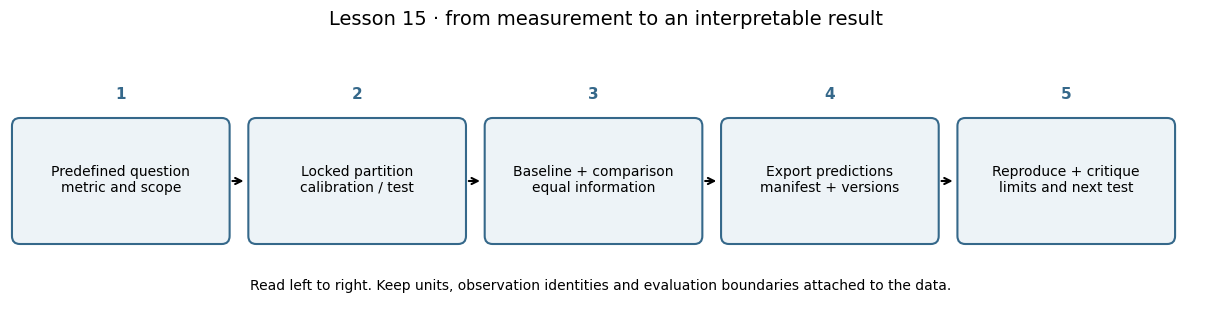

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Predefined question\nmetric and scope', 'Locked partition\ncalibration / test', 'Baseline + comparison\nequal information', 'Export predictions\nmanifest + versions', 'Reproduce + critique\nlimits and next test']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 15 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Predefined question: metric and scope → Locked partition: calibration / test → Baseline + comparison: equal information → Export predictions: manifest + versions → Reproduce + critique: limits and next test.

## Symbols and a calculation by hand

$s_{A,g},s_{B,g}$: method scores for the same independent group; $d_g$: paired difference; $M$: confusion matrix.

### Derive the operation before calling the library

Compare methods within the same evaluation groups: $d_g=s_{A,g}-s_{B,g}$, then summarize those differences. Scores A=[0.65,0.70] and B=[0.60,0.72] give differences [0.05,−0.02] and mean 0.015. An average advantage does not mean improvement in every group.

With true classes in confusion-matrix rows, recall for row $k$ is $M_{kk}/\sum_jM_{kj}$. Averaging row recalls reconstructs balanced accuracy. Recomputing a metric from exported predictions checks the result’s bookkeeping independently of the fitted model object. It cannot repair leakage in the original split, which must be audited separately.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Begin with a claim that can be tested

A useful project question specifies the participant population, task, signal, prediction target and generalization unit. “Classify EEG with AI” leaves all of these open. “Compare fixed band-power and CSP–LDA features for four-class motor imagery across two sessions of one participant” is narrow enough to evaluate and reproduce. Its conclusion must remain equally narrow.

Write the primary metric, split and candidate models before fitting. Separate exploratory plots from confirmatory evaluation. Exploration is valuable; the problem arises when choices made after seeing test results are presented as if they were specified in advance.

### Keep the experiment reconstructable

A saved score is insufficient. Preserve the dataset identifier and version, participant and session identifiers, event mapping, channels, units, preprocessing parameters, model configuration, random seed, software versions and trial-level predictions. The prediction table should contain true label, predicted label and a stable trial identifier within a documented ordering. Keep raw participant recordings out of the repository; download them from their licensed source.

A manifest is a machine-readable record of these decisions. A report explains why they were made. They complement one another: a JSON field can record `tmin=0.5`, while prose explains why the cue period was excluded. Both should agree with the executed code.

### A fair comparison changes one major factor

When comparing methods, hold the data, split, scoring and available calibration information fixed. If a neural model receives additional tuning while a linear baseline receives none, the result compares both model class and development effort. Report that difference. A useful ablation removes or changes one component while preserving the rest of the pipeline.

For paired evaluation units $g$, report $d_g=s_{A,g}-s_{B,g}$ as well as the mean difference. Consistent improvement across independent participants is stronger evidence than one favorable session. A single-participant demonstration can establish runnable methodology but cannot support a general population performance claim.

### Error analysis is part of the result

Inspect the confusion matrix and class recalls. Examine whether errors cluster in a run, late in a session or among low-quality trials. Do not use those observations to repeatedly modify the final model and keep calling the same session “unseen.” If the errors motivate a new hypothesis, mark it as exploratory and seek new evaluation data.

Describe uncertainty in terms of the available independent units. A large number of correlated windows does not create a large number of participants. Report failed downloads, exclusions and discarded trials so another analyst can reconstruct the effective sample.

### What this capstone delivers

The runnable example provides a fixed CSP–LDA baseline on a documented competition dataset with one calibration session and one held-out session. Students extend it with one justified comparison and a short model card. The deliverable includes notebook outputs, the experiment record, predictions, an error analysis and a limitations paragraph. No source imaging is required or included; all features and interpretations remain at the sensor level.

## Visual intuition · Make the confusion matrix auditable

**Try it:** Compute each row recall by hand. Why should rows, rather than columns, be normalized for recall?

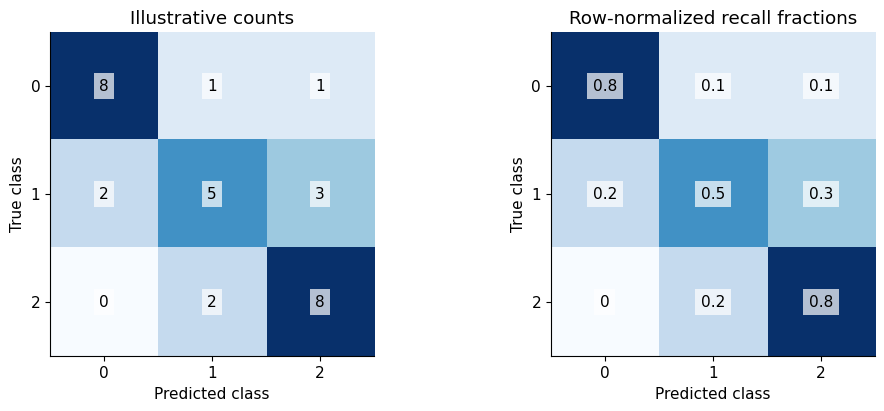

In [3]:
vis_cm=np.array([[8,1,1],[2,5,3],[0,2,8]])
vis_rec=vis_cm/vis_cm.sum(1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
for ax,values,title in zip(axes,[vis_cm,vis_rec],['Illustrative counts','Row-normalized recall fractions']):
    ax.imshow(values,cmap='Blues',aspect='equal')
    for i in range(3):
        for j in range(3):ax.text(j,i,f'{values[i,j]:.2g}',ha='center',va='center',color='black',bbox=dict(facecolor='white',alpha=.7,edgecolor='none'))
    ax.set(xticks=range(3),yticks=range(3),xlabel='Predicted class',ylabel='True class',title=title)
plt.show()

### Worked interpretation

The diagonal recalls are 0.8, 0.5 and 0.8, giving balanced accuracy 0.7. Column normalization would instead ask what fraction of a predicted class is correct. The actual capstone has four classes; this smaller matrix is for hand calculation.

## Guided practice 1 · a minimal experiment record

Build a small explicit record. Separate the development partition from the final evaluation partition.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_record={'question':'Four-class imagery across sessions','dataset':'BNCI2014_001','subject':1,'train_session':'calibration','test_session':'held out','primary_metric':'balanced_accuracy','seed':613}
print(pd.Series(demo_record))

question          Four-class imagery across sessions
dataset                                 BNCI2014_001
subject                                            1
train_session                            calibration
test_session                                held out
primary_metric                     balanced_accuracy
seed                                             613
dtype: object


### Why this result makes sense

A record should use the actual session identifiers in the final experiment. Descriptive placeholders here illustrate the fields, not the dataset’s exact naming.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · paired method comparison

Compute per-group differences before averaging. Inspect whether improvement is consistent.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_A=np.array([.65,.7,.55,.8])
demo_B=np.array([.6,.72,.5,.78])
demo_difference=demo_A-demo_B
print('Paired differences:',demo_difference,'Mean:',demo_difference.mean())

Paired differences: [ 0.05 -0.02  0.05  0.02] Mean: 0.025000000000000022


### Why this result makes sense

One method is not better in every group. A mean alone hides this heterogeneity.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · confusion to class recalls

Derive balanced accuracy from an illustrative multiclass confusion matrix with true classes in rows.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_cm=np.array([[8,1,1],[2,5,3],[0,2,8]])
demo_recall=np.diag(demo_cm)/demo_cm.sum(axis=1)
print('Class recalls:',demo_recall,'Balanced accuracy:',demo_recall.mean())

Class recalls: [0.8 0.5 0.8] Balanced accuracy: 0.7000000000000001


### Why this result makes sense

The middle class is the weak point. A targeted scientific question is more useful than trying arbitrary models until the average rises.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · prediction integrity

Check lengths, label range and a stable trial index before exporting a prediction table.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_predictions=pd.DataFrame({'trial_id':np.arange(6),'true':[0,1,2,0,1,2],'predicted':[0,1,1,0,2,2]})
assert demo_predictions.trial_id.is_unique
assert set(demo_predictions.predicted)<=set(demo_predictions.true)
assert not demo_predictions.isna().any().any()
print(demo_predictions)

   trial_id  true  predicted
0         0     0          0
1         1     1          1
2         2     2          1
3         3     0          0
4         4     1          2
5         5     2          2


### Why this result makes sense

These checks catch bookkeeping errors. They do not establish that the scientific split is valid; that must be checked separately.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Balanced accuracy from a matrix

Implement macro_recall for a confusion matrix whose true classes are rows, assuming each class has at least one observation.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def macro_recall(confusion):
    # TODO: average per-row recall.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def macro_recall(confusion):
    return np.mean(np.diag(confusion)/confusion.sum(axis=1))

In [10]:
answer=macro_recall(np.array([[8,2],[4,6]]))
if answer is not None:
    assert np.isclose(answer,.7); print('Metric check passed.')
else: print('Exercise pending: implement macro_recall.')

Metric check passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A useful scientific question specifies the population, task, signal, comparison and generalization target. “Does CSP outperform bandpower on a new session of the same participant?” is testable; “build the best BCI” is not a protocol.

Choose one primary metric before testing. For classes with unequal counts, macro recall (balanced accuracy) weights each class equally. For P300, ranking quality and precision–recall can be more informative than raw accuracy. For a complete interface, report selection accuracy and time separately from epoch classification.

Every learned stage—including artifact models, normalization, CSP, feature selection and neural networks—must be fitted only on allowed calibration data. Dataset version and subject/run selection are part of the experiment. A result without its data provenance and split definition cannot be reproduced.

## Run a complete baseline
Use this as a starting experiment, then choose one extension. Keep the held-out session locked while developing it.

The fixed baseline provides a reproducible starting point with no test-driven component search. Calibration fits CSP and LDA; the held-out session supplies predictions for the final metric and error table.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Import the named tools used in this step.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Declare the imagery class set, band and analysis interval before loading.

**5.** Expose the numerical array; EEG values are in volts and the final axis is time.

**6.** Expose the numerical array; EEG values are in volts and the final axis is time.

**7.** Make an explicit NumPy vector while preserving its current row order.

In [11]:
# Import the named tools used in this step.
from moabb.datasets import BNCI2014_001
# Import the named tools used in this step.
from moabb.paradigms import MotorImagery
# Store this intermediate result so the next operation can be traced and inspected.
dataset = BNCI2014_001()
# Declare the imagery class set, band and analysis interval before loading.
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30, tmin=0.5, tmax=3.5)
# Expose the numerical array; EEG values are in volts and the final axis is time.
epochs, y, meta = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Make an explicit NumPy vector while preserving its current row order.
y = np.asarray(y)

Choosing from all possible events


<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mak

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


### Step 1.2 · trace the next operation

**1.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**2.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**3.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**4.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**5.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**6.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**7.** Import the named tools used in this step.

In [12]:
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
sessions = meta.session.astype(str).to_numpy()
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
groups = (meta.session.astype(str) + '/' + meta.run.astype(str)).to_numpy()
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(pd.crosstab(sessions, y))
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert len(np.unique(sessions)) == 2
# Create an explicit partition mask; use the same mask for data, labels and metadata.
train = sessions == sorted(np.unique(sessions))[0]
# Create an explicit partition mask; use the same mask for data, labels and metadata.
test = ~train
# Import the named tools used in this step.
from mne.decoding import CSP

col_0   feet  left_hand  right_hand  tongue
row_0                                      
0train    72         72          72      72
1test     72         72          72      72


### Step 1.3 · trace the next operation

**1.** Keep learned preprocessing and the classifier inside the same fitting boundary.

**2.** Estimate all pipeline parameters from the training partition only.

**3.** Apply the already-fitted estimator to observations excluded from fitting.

**4.** Average class recalls so majority-class frequency does not dominate the score.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**6.** Show which true classes are confused at the current decision rule.

**7.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

Held-out session balanced accuracy: 0.7847222222222222


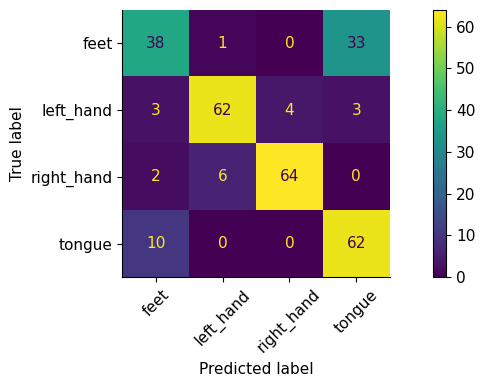

In [13]:
# Keep learned preprocessing and the classifier inside the same fitting boundary.
model = make_pipeline(CSP(n_components=4, reg='ledoit_wolf', log=True), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
# Estimate all pipeline parameters from the training partition only.
model.fit(X[train], y[train])
# Apply the already-fitted estimator to observations excluded from fitting.
pred = model.predict(X[test])
# Average class recalls so majority-class frequency does not dominate the score.
score = balanced_accuracy_score(y[test], pred)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Held-out session balanced accuracy:', score)
# Show which true classes are confused at the current decision rule.
ConfusionMatrixDisplay.from_predictions(y[test], pred, xticks_rotation=45)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
plt.tight_layout()

### Step 1.4 · trace the next operation

**1.** Render the completed figure and inspect labels, units and the comparison.

In [14]:
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Check the partition and label counts before interpreting the score. Treat this result as one participant/session-transfer example, not a population estimate.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Recompute the score from a confusion matrix

**Try it:** Use the actual four-class predictions to reconstruct balanced accuracy from row recalls.

**My reasoning / hand calculation:** _write here._

In [15]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Sort the class labels consistently in both axes.

### Worked solution

Run the following calculation after attempting your own version.

In [16]:
from sklearn.metrics import confusion_matrix
lab_labels=np.unique(y)
lab_cm=confusion_matrix(y[test],pred,labels=lab_labels)
lab_recalls=np.diag(lab_cm)/lab_cm.sum(axis=1)
print(pd.DataFrame({'class':lab_labels,'recall':lab_recalls}))
print('Reconstructed balanced accuracy:',lab_recalls.mean())
assert np.isclose(lab_recalls.mean(),score)

        class    recall
0        feet  0.527778
1   left_hand  0.861111
2  right_hand  0.888889
3      tongue  0.861111
Reconstructed balanced accuracy: 0.7847222222222222


### Interpret and check

The equality checks metric bookkeeping. The weakest class recall can guide a future scientific question, but changing the pipeline repeatedly after inspecting these test errors makes that future work exploratory on this session.

## Practice 3 · Write a claim with the correct scope

**Try it:** Complete: “Under this pipeline, the model generalized from ___ to ___ for ___.”

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Use the actual participant and session partition, not a broad population.

### Worked solution

A defensible answer is: from the calibration session to the held-out session for participant 1 in this four-class motor-imagery dataset, under the stated fixed preprocessing and CSP–LDA configuration. It does not claim transfer to every user, another headset or a live closed-loop interface.

## Export an experiment record
The JSON and table are small derived results; raw datasets remain outside the repository.

Export the configuration and trial predictions as small derived files. The notebook preserves data-loading instructions while avoiding redistribution of raw recordings. The record should be sufficient to reconstruct the reported result.

### Step 2.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Prepare the experiment metadata or output location used for reproducibility.

**3.** Prepare the experiment metadata or output location used for reproducibility.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Save the small experiment record for reproducibility; raw recordings are not redistributed.

**6.** Export aligned predictions so the metric can be reconstructed without refitting.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [17]:
# Import the named tools used in this step.
import json
# Prepare the experiment metadata or output location used for reproducibility.
record = {'dataset': 'BNCI2014-001 / BCI Competition IV 2a', 'subjects': [1], 'train_sessions': sorted(set(sessions[train])), 'test_sessions': sorted(set(sessions[test])), 'band_hz': [8, 30], 'epoch_seconds': [0.5, 3.5], 'seed': SEED, 'model': 'CSP(4, Ledoit-Wolf) + shrinkage LDA', 'n_train': int(train.sum()), 'n_test': int(test.sum()), 'balanced_accuracy': float(score), 'versions': {p: metadata.version(p) for p in ['mne', 'moabb', 'scikit-learn']}}
# Prepare the experiment metadata or output location used for reproducibility.
out = Path('capstone_results')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
out.mkdir(exist_ok=True)
# Save the small experiment record for reproducibility; raw recordings are not redistributed.
(out / 'experiment.json').write_text(json.dumps(record, indent=2))
# Export aligned predictions so the metric can be reconstructed without refitting.
pd.DataFrame({'truth': y[test], 'prediction': pred, 'session': sessions[test]}).to_csv(out / 'predictions.csv', index=False)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(json.dumps(record, indent=2))

{
  "dataset": "BNCI2014-001 / BCI Competition IV 2a",
  "subjects": [
    1
  ],
  "train_sessions": [
    "0train"
  ],
  "test_sessions": [
    "1test"
  ],
  "band_hz": [
    8,
    30
  ],
  "epoch_seconds": [
    0.5,
    3.5
  ],
  "seed": 613,
  "model": "CSP(4, Ledoit-Wolf) + shrinkage LDA",
  "n_train": 288,
  "n_test": 288,
  "balanced_accuracy": 0.7847222222222222,
  "versions": {
    "mne": "1.13.2",
    "moabb": "1.7.2",
    "scikit-learn": "1.6.1"
  }
}


### Inspect and interpret

Open the exported JSON and table, compare them with the notebook configuration and recompute the metric from the saved predictions. A mismatch is a reproducibility bug to fix before submission.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Reproduce the metric from the saved artifact

**Try it:** Read the exported predictions from disk and recompute the score without asking the model to predict again.

**My reasoning / hand calculation:** _write here._

In [18]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The file should carry the true and predicted labels in the same row order.

### Worked solution

Run the following calculation after attempting your own version.

In [19]:
lab_saved=pd.read_csv(out/'predictions.csv')
lab_saved_score=balanced_accuracy_score(lab_saved.truth,lab_saved.prediction)
print('Saved rows:',len(lab_saved),'recomputed score:',lab_saved_score)
assert len(lab_saved)==int(test.sum())
assert np.isclose(lab_saved_score,record['balanced_accuracy'])

Saved rows: 288 recomputed score: 0.7847222222222222


### Interpret and check

A mismatch would indicate an export, ordering or record error. Matching confirms that the saved predictions support the reported metric; it does not independently validate the original split or data provenance.

## Practice 5 · Plan one fair next comparison

**Try it:** Which parts of the experiment must stay fixed when comparing CSP–LDA with another feature/model combination?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Control the information and evaluation budget as well as the data.

### Worked solution

Keep the participant/session split, eligible trials, event definitions, primary metric and calibration information fixed. Tune both methods within calibration data with a stated search budget. Record all configurations and predictions. If the current test results influenced the new choice, use a new independent evaluation for the final claim.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

A reproducible BCI result connects a narrow question, documented partition, justified method, saved predictions and appropriately limited conclusion. The next experiment should target the largest unresolved generalization question rather than only chase a higher reused-test score.

## If your result is different

If an exported metric disagrees, inspect row ordering, label types, class set and prediction file freshness before rerunning model fitting.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[Course evaluation guide](../docs/guides/evaluation.md) · [Competition dataset](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.